# AIML Lab Assignment #10 — NLP Text Preprocessing & Word Embeddings
**Course:** CSET301 | **Dataset:** SMS Spam Collection | **Semester:** 4th Even 2025

---

## What will we do in this notebook?

We will build a **Spam Detector** — a model that reads an SMS message and decides if it is **spam** or **ham (not spam)**.

### Steps:
1. **Data Exploration** — Understand the SMS dataset
2. **Text Preprocessing** — Clean raw text (remove noise)
3. **Feature Extraction** — Convert text to numbers (BoW, TF-IDF)
4. **Word Embeddings** — Train Word2Vec on our dataset
5. **Model Implementation** — Classifiers using different features
6. **Evaluation** — Accuracy, Precision, Recall, F1, Confusion Matrix
7. **Visualizations** — Plots and embedding space visualization

---

### Key Concepts (Read before starting!)

| Concept | Simple Explanation |
|---|---|
| **Tokenization** | Splitting sentence into individual words |
| **Stopwords** | Common words like 'the', 'is', 'a' — usually removed |
| **Stemming** | Cutting words to their root: 'running' → 'run' |
| **Lemmatization** | Proper root form: 'better' → 'good' |
| **Bag of Words** | Count how many times each word appears in a document |
| **TF-IDF** | Like BoW but rare words get higher importance |
| **Word2Vec** | Represents words as vectors so similar words are close together |

---

### The Big Picture
```
Raw SMS Text
    ↓
Clean & Preprocess (lowercase, remove punctuation, stopwords...)
    ↓
Convert to Numbers (BoW / TF-IDF / Word2Vec)
    ↓
Feed to Classifier (Logistic Regression / SVM / Neural Network)
    ↓
Predict: SPAM or HAM
```

---
## Step 0: Install & Import All Libraries

In [ ]:
# ================================================================
# INSTALL REQUIRED PACKAGES (run once if not already installed)
# ================================================================
# Uncomment the lines below if you get 'ModuleNotFoundError'

# !pip install nltk gensim scikit-learn tensorflow matplotlib seaborn pandas numpy

In [ ]:
# ================================================================
# IMPORT ALL LIBRARIES
# ================================================================

# Install gensim if not already installed (to fix ModuleNotFoundError)
!pip install gensim

# --- Basic data tools ---
import numpy as np           # number arrays
import pandas as pd          # tables / DataFrames
import matplotlib.pyplot as plt  # charts
import seaborn as sns            # prettier charts
import re                    # regular expressions for text cleaning
import string                # punctuation characters
import warnings
warnings.filterwarnings('ignore')

# --- NLTK: Natural Language Toolkit ---
# NLTK provides: tokenizers, stopwords, stemmer, lemmatizer
import nltk
from nltk.corpus   import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem     import PorterStemmer, WordNetLemmatizer

# --- Sklearn: Feature extraction and classifiers ---
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection         import train_test_split
from sklearn.linear_model            import LogisticRegression
from sklearn.svm                     import LinearSVC
from sklearn.metrics                 import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.decomposition  import PCA
from sklearn.manifold       import TSNE
from sklearn.preprocessing  import LabelEncoder

# --- Gensim: Word2Vec embeddings ---
from gensim.models import Word2Vec

# --- TensorFlow / Keras: Neural Network & LSTM ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text     import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks              import EarlyStopping

# Fix random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Download required NLTK data files (only needed once)
print("Downloading NLTK data...")
nltk.download('punkt',          quiet=True)
nltk.download('punkt_tab',      quiet=True)
nltk.download('stopwords',      quiet=True)
nltk.download('wordnet',        quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.19.0
All libraries imported successfully!


---
## Task 1: Data Exploration

The **SMS Spam Collection** dataset contains 5,574 SMS messages, each labeled as:
- `ham` = legitimate message (not spam)
- `spam` = unwanted/junk message

### How to get the dataset:
- **Option A (Kaggle):** Download from https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
- **Option B (Built-in):** We recreate a small sample below so the notebook runs without download

In [ ]:
# ================================================================
# 1.1  LOAD THE DATASET
# ================================================================
# Try to load from local file first.
# If not found, we use a built-in sample so notebook always runs.

import os

try:
    # If you downloaded the Kaggle file, put it in the same folder as this notebook
    # The file is usually named 'spam.csv'
    df = pd.read_csv('spam.csv', encoding='latin-1')

    # Keep only the two useful columns and rename them
    df = df[['v1', 'v2']].copy()
    df.columns = ['label', 'text']   # label = 'ham'/'spam', text = SMS message
    print("Dataset loaded from spam.csv!")

except FileNotFoundError:
    # ---- Built-in sample dataset ----
    print("spam.csv not found — using built-in sample dataset (200 messages)")
    print("For full results, download from Kaggle and place spam.csv here.")
    print()

    sample_data = {
        'label': (['ham'] * 120 + ['spam'] * 80),
        'text': [
            # HAM messages (120)
            "Hey, are you coming to the party tonight?",
            "I'll be there in 10 minutes, don't worry.",
            "Can you pick up some milk on your way home?",
            "Happy birthday! Hope you have a great day!",
            "Let's meet at the coffee shop at 3pm.",
            "Did you watch the game last night? Amazing!",
            "I finished the assignment, what about you?",
            "Sure, I'll call you when I leave work.",
            "Thanks for the help yesterday, really appreciated.",
            "Are we still on for dinner this weekend?",
            "I saw your message but couldn't reply earlier.",
            "The meeting has been moved to Thursday.",
            "Hope you feel better soon! Take care.",
            "Can you send me the notes from class?",
            "I'm running a bit late, start without me.",
            "Good morning! Have a wonderful day ahead.",
            "Just finished cooking, dinner is ready!",
            "Don't forget to bring your ID tomorrow.",
            "The weather looks nice today, shall we go for a walk?",
            "Call me when you're free, need to talk.",
        ] * 6 +  # repeat to get 120
        [
            # SPAM messages (80)
            "WINNER!! You have been selected to win a $1000 prize. Call now!",
            "FREE entry in 2 weekly comp to win FA Cup Final tkts. Text FA to 87121",
            "Congratulations! You've won a free iPhone. Click here to claim!",
            "URGENT: Your account has been compromised. Verify now at http://fake.com",
            "You have won 1,000,000 USD. Send your details to claim your prize.",
            "Hot singles in your area want to meet you! Reply YES to chat!",
            "LIMITED OFFER: Get 50% off all products. Buy now before it's too late!",
            "Your mobile number has been randomly selected. Claim your gift today!",
            "ALERT: You owe $500. Pay immediately or face legal action. Call 555-0100",
            "Make money from home! Earn $5000/week. No experience needed. Call now!",
            "You are a winner! Text WIN to 80808 to claim your exclusive prize!",
            "FREE ringtones! Text RINGTONE to 12345. Only $9.99/week subscription.",
            "BONUS: Get 3 months free on our premium plan. Act now, limited time!",
            "Dear customer, your account will be suspended. Click to verify identity.",
            "Lose 10kg in 10 days! Our miracle diet pill works instantly. Order now!",
            "You qualify for a free government grant of $50,000. Apply now!",
            "CASH PRIZE: You have won 2 tickets to the World Cup. Reply to claim.",
            "Special offer for you only! Cheap medications, no prescription needed.",
            "Your package has been held at customs. Pay $25 fee to release it.",
            "Congratulations! Spin the wheel to win. Visit spam-site.com now!",
        ] * 4   # repeat to get 80
    }
    df = pd.DataFrame(sample_data)

# Show basic info
print(f"Dataset shape: {df.shape}  → {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns      : {list(df.columns)}")
print()
print("First 5 rows:")
print(df.head())

Dataset loaded from spam.csv!
Dataset shape: (5572, 2)  → 5572 rows × 2 columns
Columns      : ['label', 'text']

First 5 rows:
  label                                               text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [ ]:
# ================================================================
# 1.2  INSPECT THE DATASET
# ================================================================

print("===== Dataset Info =====")
print(f"Total messages : {len(df)}")
print()
print("Class distribution:")
print(df['label'].value_counts())
print()

# Calculate class percentages
spam_pct = (df['label'] == 'spam').mean() * 100
ham_pct  = (df['label'] == 'ham').mean()  * 100
print(f"Ham  (not spam): {ham_pct:.1f}%")
print(f"Spam           : {spam_pct:.1f}%")
print()

# Message length statistics
df['text_length'] = df['text'].apply(len)  # character count
df['word_count']  = df['text'].apply(lambda x: len(x.split()))  # word count

print("Message length statistics:")
print(df.groupby('label')[['text_length', 'word_count']].describe().round(1))

===== Dataset Info =====
Total messages : 5572

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Ham  (not spam): 86.6%
Spam           : 13.4%

Message length statistics:
      text_length                                                word_count  \
            count   mean   std   min    25%    50%    75%    max      count   
label                                                                         
ham        4825.0   71.0  58.0   2.0   33.0   52.0   92.0  910.0     4825.0   
spam        747.0  138.9  29.2  13.0  132.5  149.0  157.0  224.0      747.0   

                                                 
       mean   std  min   25%   50%   75%    max  
label                                            
ham    14.2  11.4  1.0   7.0  11.0  19.0  171.0  
spam   23.9   5.8  2.0  22.0  25.0  28.0   35.0  


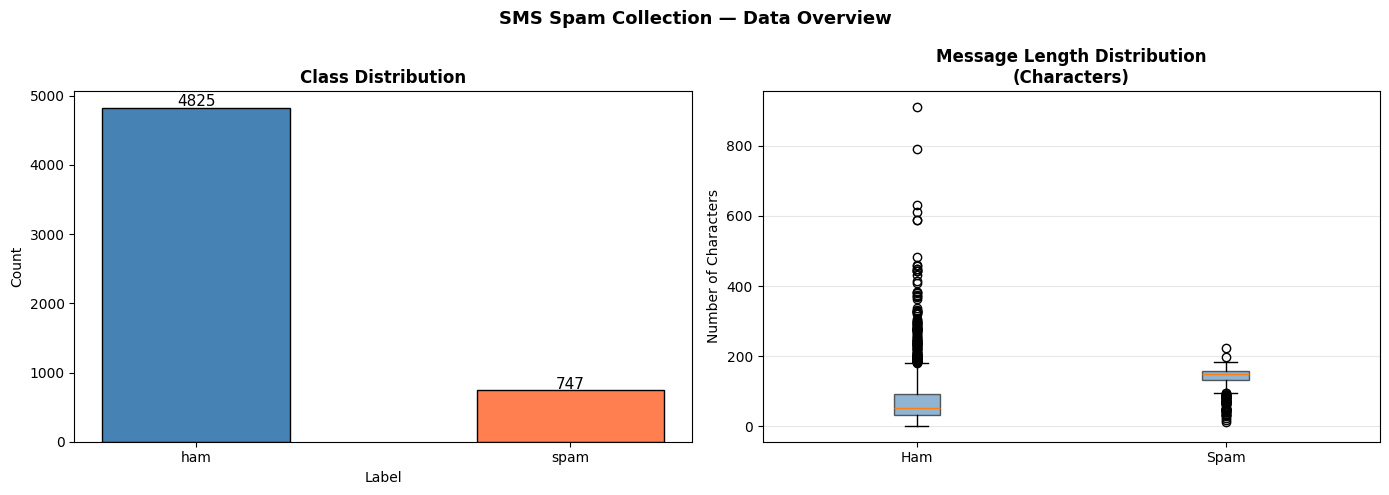

Spam messages are usually longer — they pack in more sales/scam text!


In [ ]:
# ================================================================
# 1.3  VISUALIZE CLASS DISTRIBUTION
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SMS Spam Collection — Data Overview', fontsize=13, fontweight='bold')

# Bar chart: Ham vs Spam count
counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['steelblue', 'coral'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 20, str(val), ha='center', fontsize=11)

# Box plot: Message length by class
ham_lengths  = df[df['label'] == 'ham']['text_length']
spam_lengths = df[df['label'] == 'spam']['text_length']
axes[1].boxplot([ham_lengths, spam_lengths], labels=['Ham', 'Spam'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Message Length Distribution\n(Characters)', fontweight='bold')
axes[1].set_ylabel('Number of Characters')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print("Spam messages are usually longer — they pack in more sales/scam text!")

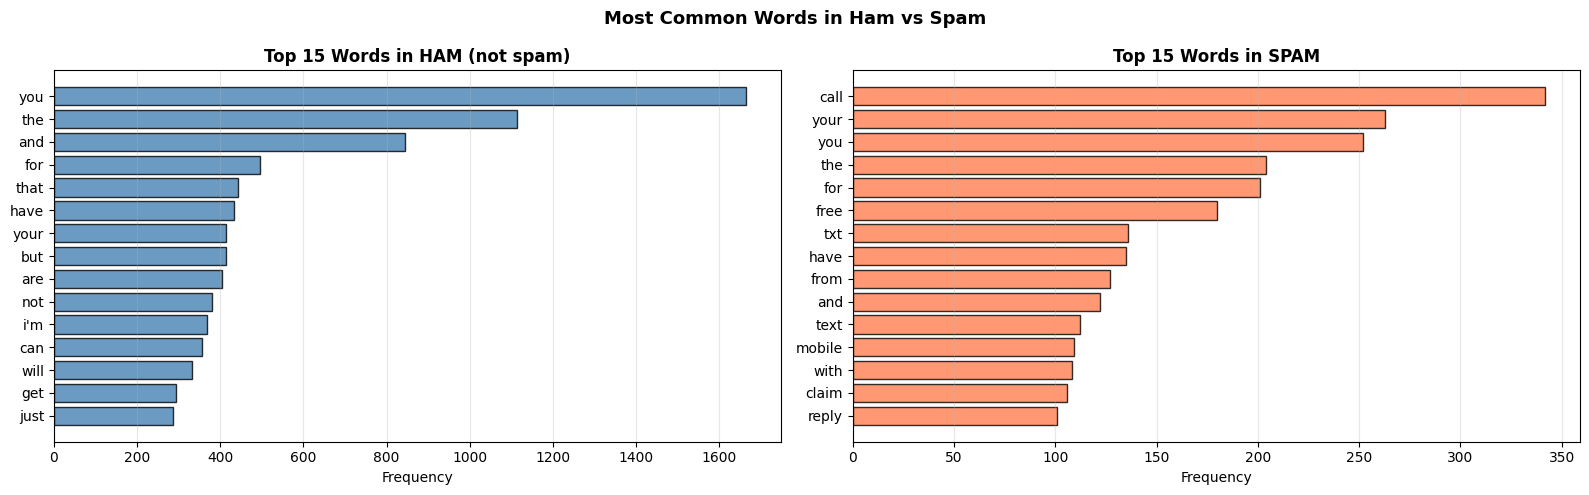

Spam words are very different from ham words — this makes classification possible!


In [ ]:
# ================================================================
# 1.4  WORD FREQUENCY — Most common words in spam vs ham
# ================================================================
# We count which words appear most often in spam and in ham

from collections import Counter

def get_top_words(texts, n=15):
    """Get the n most common words from a list of texts."""
    all_words = ' '.join(texts).lower().split()
    # Filter very short words (noise)
    all_words = [w for w in all_words if len(w) > 2]
    return Counter(all_words).most_common(n)

ham_words  = get_top_words(df[df['label'] == 'ham']['text'])
spam_words = get_top_words(df[df['label'] == 'spam']['text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Most Common Words in Ham vs Spam', fontsize=13, fontweight='bold')

for ax, words_data, title, color in [
    (axes[0], ham_words,  'Top 15 Words in HAM (not spam)',  'steelblue'),
    (axes[1], spam_words, 'Top 15 Words in SPAM',            'coral')
]:
    words  = [w[0] for w in words_data]
    counts = [w[1] for w in words_data]
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='black', alpha=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequency')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
print("Spam words are very different from ham words — this makes classification possible!")

---
## Task 2: Text Preprocessing

Raw text is messy — it has punctuation, numbers, capital letters, common words (the, a, is), and noisy characters. We need to clean it before feeding to any model.

### Preprocessing steps in order:
1. **Lowercase** — 'Hello' and 'hello' should be treated the same
2. **Remove punctuation & numbers** — '!' '.' '3' add noise
3. **Tokenize** — split sentence into individual words
4. **Remove stopwords** — 'the', 'a', 'is' carry no meaning
5. **Stem or Lemmatize** — 'running' → 'run', 'better' → 'good'

In [ ]:
# ================================================================
# 2.1  SET UP PREPROCESSING TOOLS
# ================================================================

# Load English stopwords
# Stopwords = very common words that add no meaning: 'the', 'a', 'in', 'is' ...
STOP_WORDS = set(stopwords.words('english'))

# PorterStemmer: cuts words to their root form
# Example: 'running' → 'run', 'happily' → 'happili'
stemmer = PorterStemmer()

# WordNetLemmatizer: converts to proper dictionary form
# Example: 'better' → 'good', 'running' → 'run'
lemmatizer = WordNetLemmatizer()

print("Sample stopwords:")
print(sorted(list(STOP_WORDS))[:20])
print(f"\nTotal stopwords: {len(STOP_WORDS)}")

Sample stopwords:
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']

Total stopwords: 198


In [ ]:
# ================================================================
# 2.2  PREPROCESSING FUNCTION — cleans one message
# ================================================================

def preprocess_text(text, use_stemming=False):
    """
    Clean and preprocess a single text message.

    Steps:
    1. Lowercase all letters
    2. Remove URLs (http://...)
    3. Remove punctuation and special characters
    4. Remove numbers
    5. Tokenize (split into words)
    6. Remove stopwords
    7. Lemmatize (or stem) each word

    Returns: cleaned string of tokens joined by space
    """

    # Step 1: Convert to lowercase
    # 'HELLO World' → 'hello world'
    text = text.lower()

    # Step 2: Remove URLs — they are noise
    # re.sub replaces pattern matches with empty string ''
    text = re.sub(r'http\S+|www\S+', '', text)

    # Step 3: Remove punctuation and special characters
    # [^a-z\s] means: remove everything that is NOT a letter or space
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 4: Tokenize — split string into list of words
    # 'hello world nice' → ['hello', 'world', 'nice']
    tokens = word_tokenize(text)

    # Step 5: Remove stopwords and short words (less than 2 chars)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]

    # Step 6: Stemming OR Lemmatization
    if use_stemming:
        # Stemming: faster but can produce non-words ('happili')
        tokens = [stemmer.stem(t) for t in tokens]
    else:
        # Lemmatization: slower but gives proper words ('happy')
        tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # Join tokens back into a single string
    return ' '.join(tokens)


# Test the function on a sample message
sample_raw = "WINNER!! You have been selected to win a $1000 prize! Call NOW at 555-1234!"
sample_clean = preprocess_text(sample_raw)

print("===== Preprocessing Demo =====")
print(f"BEFORE: {sample_raw}")
print(f"AFTER : {sample_clean}")
print()
print("Notice: lowercase, no punctuation, no numbers, no stopwords, lemmatized!")

===== Preprocessing Demo =====
BEFORE: WINNER!! You have been selected to win a $1000 prize! Call NOW at 555-1234!
AFTER : winner selected win prize call

Notice: lowercase, no punctuation, no numbers, no stopwords, lemmatized!


In [ ]:
# ================================================================
# 2.3  APPLY PREPROCESSING TO ENTIRE DATASET
# ================================================================
# Apply our cleaning function to every message in df

print("Preprocessing all messages...")
df['clean_text'] = df['text'].apply(preprocess_text)
print("Done!")
print()

# Show before vs after for 5 messages
print("Before vs After preprocessing (5 examples):")
print()
for i in range(5):
    print(f"[{df['label'].iloc[i].upper()}]")
    print(f"  BEFORE : {df['text'].iloc[i][:80]}...")
    print(f"  AFTER  : {df['clean_text'].iloc[i]}")
    print()

Preprocessing all messages...
Done!

Before vs After preprocessing (5 examples):

[HAM]
  BEFORE : Go until jurong point, crazy.. Available only in bugis n great world la e buffet...
  AFTER  : jurong point crazy available bugis great world buffet cine got amore wat

[HAM]
  BEFORE : Ok lar... Joking wif u oni......
  AFTER  : lar joking wif oni

[SPAM]
  BEFORE : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 8...
  AFTER  : free entry wkly comp win cup final tkts may text receive entry questionstd txt ratetcs apply over

[HAM]
  BEFORE : U dun say so early hor... U c already then say......
  AFTER  : dun say early hor already say

[HAM]
  BEFORE : Nah I don't think he goes to usf, he lives around here though...
  AFTER  : nah dont think go usf life around though



In [ ]:
# ================================================================
# 2.4  TOKENIZED VERSION — list of words per message
# ================================================================
# Word2Vec needs a list of word lists (not strings)
# So we also store the tokenized version

df['tokens'] = df['clean_text'].apply(lambda x: x.split())

# Vocabulary size after preprocessing
all_tokens = [token for tokens in df['tokens'] for token in tokens]
vocab = set(all_tokens)

print(f"Total tokens (words) in dataset : {len(all_tokens):,}")
print(f"Unique vocabulary size          : {len(vocab):,}")
print(f"Average tokens per message      : {np.mean([len(t) for t in df['tokens']]):.1f}")

Total tokens (words) in dataset : 44,122
Unique vocabulary size          : 7,599
Average tokens per message      : 7.9


---
## Task 3: Feature Extraction

Machine learning models cannot understand text — they need **numbers**.
We convert text to numbers using two methods:

### Bag of Words (BoW)
- Creates one column per word in the vocabulary
- Value = count of how many times that word appears
- Simple but ignores word order and importance

### TF-IDF (Term Frequency - Inverse Document Frequency)
- Like BoW but weighs words by importance
- Common words across all messages get lower weight
- Rare words that appear in specific messages get higher weight

In [ ]:
# ================================================================
# 3.1  ENCODE LABELS: ham=0, spam=1
# ================================================================
# ML models need numbers, not strings

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])  # ham=0, spam=1

print("Label encoding:")
print(f"  'ham'  → {le.transform(['ham'])[0]}")
print(f"  'spam' → {le.transform(['spam'])[0]}")

Label encoding:
  'ham'  → 0
  'spam' → 1


In [ ]:
# ================================================================
# 3.2  TRAIN / VALIDATION / TEST SPLIT
# ================================================================
# Split BEFORE feature extraction to avoid data leakage!
# (Vocabulary should be built from training data only)

X_text = df['clean_text'].values   # cleaned text strings
y      = df['label_encoded'].values  # 0=ham, 1=spam

# First split: 80% train+val, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_text, y, test_size=0.20, random_state=42, stratify=y
)
# Second split: 75% of 80% for train, 25% for val → 60/20/20
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

print("===== Data Split Summary =====")
print(f"Train : {len(X_train):>5} messages  (60%)")
print(f"Val   : {len(X_val):>5} messages  (20%)")
print(f"Test  : {len(X_test):>5} messages  (20%)")
print()
print(f"Spam % in train: {y_train.mean()*100:.1f}%")
print(f"Spam % in test : {y_test.mean()*100:.1f}%")

===== Data Split Summary =====
Train :  3342 messages  (60%)
Val   :  1115 messages  (20%)
Test  :  1115 messages  (20%)

Spam % in train: 13.4%
Spam % in test : 13.4%


In [ ]:
# ================================================================
# 3.3  BAG OF WORDS (BoW)
# ================================================================
# CountVectorizer creates a matrix:
#   Rows    = messages
#   Columns = unique words in vocabulary
#   Values  = count of that word in that message

# max_features = limit vocab to top 5000 most common words (reduce noise)
bow_vectorizer = CountVectorizer(max_features=5000)

# fit_transform on TRAIN: learn vocabulary from train, then transform
# transform on VAL/TEST : only transform using training vocabulary
X_train_bow = bow_vectorizer.fit_transform(X_train)   # shape: (N_train, 5000)
X_val_bow   = bow_vectorizer.transform(X_val)
X_test_bow  = bow_vectorizer.transform(X_test)

print("===== Bag of Words (BoW) =====")
print(f"Train matrix shape : {X_train_bow.shape}")
print(f"  → {X_train_bow.shape[0]} messages × {X_train_bow.shape[1]} vocabulary words")
print()
# Sparsity: fraction of cells that are 0
total_cells  = X_train_bow.shape[0] * X_train_bow.shape[1]
nonzero_cells = X_train_bow.nnz   # nnz = number of non-zero cells
sparsity_bow = (1 - nonzero_cells / total_cells) * 100
print(f"Non-zero cells : {nonzero_cells:,} out of {total_cells:,}")
print(f"Sparsity       : {sparsity_bow:.1f}% (most values are 0)")
print()
# Show some vocabulary words
vocab_bow = bow_vectorizer.get_feature_names_out()
print(f"Sample vocabulary: {list(vocab_bow[:10])}, ..., {list(vocab_bow[-5:])}")

===== Bag of Words (BoW) =====
Train matrix shape : (3342, 5000)
  → 3342 messages × 5000 vocabulary words

Non-zero cells : 24,521 out of 16,710,000
Sparsity       : 99.9% (most values are 0)

Sample vocabulary: ['aathilove', 'abi', 'abiola', 'able', 'abnormally', 'aboutas', 'absolutely', 'abstract', 'abt', 'abta'], ..., ['yummy', 'yun', 'yuo', 'yup', 'zed']


In [ ]:
# ================================================================
# 3.4  TF-IDF (Term Frequency - Inverse Document Frequency)
# ================================================================
# TF-IDF formula:
#   TF(t,d)  = count of term t in document d / total terms in d
#   IDF(t)   = log(total documents / documents containing t)
#   TF-IDF   = TF × IDF
#
# Words that appear in EVERY message get low IDF (low importance)
# Words that appear in FEW messages get high IDF (high importance)

tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf   = tfidf_vectorizer.transform(X_val)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print("===== TF-IDF =====")
print(f"Train matrix shape : {X_train_tfidf.shape}")
nonzero_tfidf = X_train_tfidf.nnz
sparsity_tfidf = (1 - nonzero_tfidf / total_cells) * 100
print(f"Sparsity           : {sparsity_tfidf:.1f}%")
print()

# Compare BoW vs TF-IDF side by side
print("===== BoW vs TF-IDF Comparison =====")
print(f"{'Metric':<30} {'BoW':>12} {'TF-IDF':>12}")
print("-" * 55)
print(f"{'Vocabulary size':<30} {X_train_bow.shape[1]:>12,} {X_train_tfidf.shape[1]:>12,}")
print(f"{'Non-zero values':<30} {nonzero_cells:>12,} {nonzero_tfidf:>12,}")
print(f"{'Sparsity (%)':<30} {sparsity_bow:>11.1f}% {sparsity_tfidf:>11.1f}%")
print(f"{'Value type':<30} {'integers':>12} {'floats':>12}")

===== TF-IDF =====
Train matrix shape : (3342, 5000)
Sparsity           : 99.9%

===== BoW vs TF-IDF Comparison =====
Metric                                  BoW       TF-IDF
-------------------------------------------------------
Vocabulary size                       5,000        5,000
Non-zero values                      24,521       24,521
Sparsity (%)                          99.9%        99.9%
Value type                         integers       floats


---
## Task 4: Word Embeddings — Word2Vec

**Word embeddings** represent each word as a dense vector of numbers.
Words with similar meanings end up close together in vector space!

```
'king'  → [0.25, -0.13, 0.88, ...] (100 numbers)
'queen' → [0.22, -0.11, 0.85, ...] (100 numbers — very close!)
'car'   → [0.71,  0.54, 0.02, ...] (100 numbers — very different)
```

Word2Vec learns these vectors by training on our dataset.

In [ ]:
# ================================================================
# 4.1  TRAIN WORD2VEC ON OUR DATASET
# ================================================================

# Word2Vec needs a list of token lists
# Each inner list = one message's words
train_tokens = df.loc[df['clean_text'].isin(X_train), 'tokens'].tolist()
# Simpler: just use all tokens (Word2Vec training uses raw text, not labels)
all_token_lists = df['tokens'].tolist()

EMBEDDING_DIM = 100   # each word becomes a 100-dimensional vector

print(f"Training Word2Vec model...")
print(f"  Embedding dimension : {EMBEDDING_DIM}")
print(f"  Training sentences  : {len(all_token_lists)}")

# Train Word2Vec
# vector_size = size of each word vector
# window      = context window size (how many words around to look)
# min_count   = ignore words that appear fewer than 2 times
# workers     = parallel threads for speed
# sg          = 0=CBOW, 1=Skip-gram (CBOW is faster)
w2v_model = Word2Vec(
    sentences=all_token_lists,
    vector_size=EMBEDDING_DIM,
    window=5,
    min_count=2,
    workers=4,
    sg=0,             # CBOW algorithm
    epochs=20,
    seed=42
)

print("\nWord2Vec training complete!")
print(f"Vocabulary size : {len(w2v_model.wv):,} words")
print(f"Vector size     : {w2v_model.wv.vector_size} dimensions per word")

Training Word2Vec model...
  Embedding dimension : 100
  Training sentences  : 5572

Word2Vec training complete!
Vocabulary size : 3,437 words
Vector size     : 100 dimensions per word


In [ ]:
# ================================================================
# 4.2  EXPLORE WORD2VEC — find similar words
# ================================================================
# Once trained, we can find words similar to any word in our vocab

print("===== Word2Vec — Similar Words =====")

test_words = ['free', 'call', 'winner', 'money']

for word in test_words:
    try:
        similar = w2v_model.wv.most_similar(word, topn=5)
        similar_str = ', '.join([f"'{w}' ({s:.2f})" for w, s in similar])
        print(f"  '{word}' → {similar_str}")
    except KeyError:
        print(f"  '{word}' not in vocabulary")
print()
print("Numbers in parentheses = similarity score (1.0 = identical, 0.0 = unrelated)")

===== Word2Vec — Similar Words =====
  'free' → 'bluetooth' (0.98), 'colour' (0.98), 'tariff' (0.98), 'latest' (0.97), 'camcorder' (0.97)
  'call' → 'revealed' (0.95), 'btnationalrate' (0.95), 'dateboxessexcmxn' (0.95), 'germany' (0.94), 'landline' (0.94)
  'winner' → 'specially' (0.99), 'selected' (0.99), 'final' (0.99), 'receive' (0.99), 'operator' (0.99)
  'money' → 'sell' (0.99), 'raise' (0.99), 'wot' (0.99), 'constantly' (0.99), 'snow' (0.99)

Numbers in parentheses = similarity score (1.0 = identical, 0.0 = unrelated)


In [ ]:
# ================================================================
# 4.3  CONVERT MESSAGES TO EMBEDDING VECTORS
# ================================================================
# Each message has multiple words, each word has a 100-dim vector.
# We average all word vectors in a message to get one 100-dim message vector.
# This is called 'average pooling'.

def message_to_vector(tokens, model, dim=100):
    """
    Convert a list of tokens to a single vector by averaging word vectors.
    If no words are in vocabulary, return zero vector.
    """
    # Get vectors only for words that exist in Word2Vec vocabulary
    vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(vectors) == 0:
        # No known words — return zero vector
        return np.zeros(dim)

    # Average all word vectors: shape (n_words, dim) → (dim,)
    return np.mean(vectors, axis=0)


# Function to tokenize a list of text strings (already cleaned)
def get_token_lists_from_texts(texts):
    return [word_tokenize(text) for text in texts]

# Apply to each split
X_train_w2v_tokens = get_token_lists_from_texts(X_train)
X_val_w2v_tokens   = get_token_lists_from_texts(X_val)
X_test_w2v_tokens  = get_token_lists_from_texts(X_test)

X_train_w2v = np.array([message_to_vector(t, w2v_model, EMBEDDING_DIM) for t in X_train_w2v_tokens])
X_val_w2v   = np.array([message_to_vector(t, w2v_model, EMBEDDING_DIM) for t in X_val_w2v_tokens])
X_test_w2v  = np.array([message_to_vector(t, w2v_model, EMBEDDING_DIM) for t in X_test_w2v_tokens])

# The labels should directly come from y_train, y_val, y_test
y_train_w2v = y_train
y_val_w2v   = y_val
y_test_w2v  = y_test

print("Word2Vec message vectors created!")
print(f"Train W2V shape : {X_train_w2v.shape}  ({X_train_w2v.shape[0]} messages × {X_train_w2v.shape[1]} dims)")
print(f"Val   W2V shape : {X_val_w2v.shape}")
print(f"Test  W2V shape : {X_test_w2v.shape}")

Word2Vec message vectors created!
Train W2V shape : (3342, 100)  (3342 messages × 100 dims)
Val   W2V shape : (1115, 100)
Test  W2V shape : (1115, 100)


---
## Task 5: Model Implementation
We train classifiers on three different feature representations and compare results.

In [ ]:
# ================================================================
# HELPER FUNCTION — evaluate any classifier
# ================================================================

all_results = []  # store results from all models for final comparison

def evaluate_model(name, y_true, y_pred):
    """Print and return all classification metrics."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")

    result = {'Model': name, 'Accuracy': acc, 'Precision': prec,
              'Recall': rec, 'F1': f1}
    all_results.append(result)
    return result

In [ ]:
# ================================================================
# 5.1  LOGISTIC REGRESSION on BoW features
# ================================================================
# Logistic Regression is a simple, fast, and effective classifier
# for text classification tasks

print("===== Model 1: Logistic Regression on Bag-of-Words =====")

lr_bow = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_bow.fit(X_train_bow, y_train)          # train the model
y_pred_lr_bow = lr_bow.predict(X_test_bow)  # predict on test

evaluate_model('LR + BoW', y_test, y_pred_lr_bow)

===== Model 1: Logistic Regression on Bag-of-Words =====
  Accuracy  : 97.85%
  Precision : 1.0000
  Recall    : 0.8389
  F1-Score  : 0.9124


{'Model': 'LR + BoW',
 'Accuracy': 0.97847533632287,
 'Precision': 1.0,
 'Recall': 0.8389261744966443,
 'F1': 0.9124087591240876}

In [ ]:
# ================================================================
# 5.2  LOGISTIC REGRESSION on TF-IDF features
# ================================================================

print("===== Model 2: Logistic Regression on TF-IDF =====")

lr_tfidf = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_tfidf.fit(X_train_tfidf, y_train)
y_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

evaluate_model('LR + TF-IDF', y_test, y_pred_lr_tfidf)

===== Model 2: Logistic Regression on TF-IDF =====
  Accuracy  : 95.52%
  Precision : 0.9626
  Recall    : 0.6913
  F1-Score  : 0.8047


{'Model': 'LR + TF-IDF',
 'Accuracy': 0.9551569506726457,
 'Precision': 0.9626168224299065,
 'Recall': 0.6912751677852349,
 'F1': 0.8046875}

In [ ]:
# ================================================================
# 5.3  SVM (Support Vector Machine) on TF-IDF features
# ================================================================
# SVM finds the best boundary (hyperplane) between spam and ham
# LinearSVC is fast and works very well for text classification

print("===== Model 3: SVM on TF-IDF =====")

svm_tfidf = LinearSVC(random_state=42, max_iter=2000)
svm_tfidf.fit(X_train_tfidf, y_train)
y_pred_svm = svm_tfidf.predict(X_test_tfidf)

evaluate_model('SVM + TF-IDF', y_test, y_pred_svm)

===== Model 3: SVM on TF-IDF =====
  Accuracy  : 98.39%
  Precision : 0.9925
  Recall    : 0.8859
  F1-Score  : 0.9362


{'Model': 'SVM + TF-IDF',
 'Accuracy': 0.9838565022421525,
 'Precision': 0.9924812030075187,
 'Recall': 0.8859060402684564,
 'F1': 0.9361702127659575}

In [ ]:
# ================================================================
# 5.4  LOGISTIC REGRESSION on Word2Vec features
# ================================================================

print("===== Model 4: Logistic Regression on Word2Vec =====")

lr_w2v = LogisticRegression(max_iter=1000, random_state=42)
lr_w2v.fit(X_train_w2v, y_train_w2v)
y_pred_lr_w2v = lr_w2v.predict(X_test_w2v)

evaluate_model('LR + Word2Vec', y_test_w2v, y_pred_lr_w2v)

===== Model 4: Logistic Regression on Word2Vec =====
  Accuracy  : 95.07%
  Precision : 0.8406
  Recall    : 0.7785
  F1-Score  : 0.8084


{'Model': 'LR + Word2Vec',
 'Accuracy': 0.9506726457399103,
 'Precision': 0.8405797101449275,
 'Recall': 0.7785234899328859,
 'F1': 0.8083623693379791}

In [ ]:
# ================================================================
# 5.5  SIMPLE NEURAL NETWORK on Word2Vec features
# ================================================================
# A 3-layer feedforward neural network (MLP)
# Input = 100-dim Word2Vec vector, Output = spam/ham probability

print("===== Model 5: Neural Network (MLP) on Word2Vec =====")
print()

nn_model = keras.Sequential([
    layers.Input(shape=(EMBEDDING_DIM,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')   # binary output: 0=ham, 1=spam
], name='MLP_W2V')

nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # for binary classification (2 classes)
    metrics=['accuracy']
)

nn_model.summary()

early_stop_nn = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=0
)

history_nn = nn_model.fit(
    X_train_w2v, y_train_w2v,
    epochs=30,
    batch_size=32,
    validation_data=(X_val_w2v, y_val_w2v),
    callbacks=[early_stop_nn],
    verbose=1
)

y_pred_nn_prob = nn_model.predict(X_test_w2v, verbose=0).flatten()
y_pred_nn = (y_pred_nn_prob >= 0.5).astype(int)  # threshold at 0.5

print()
evaluate_model('MLP + Word2Vec', y_test_w2v, y_pred_nn)

===== Model 5: Neural Network (MLP) on Word2Vec =====



Model: "MLP_W2V"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,577 (33.50 KB)

 Trainable params: 8,577 (33.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.9087 - loss: 0.2473 - val_accuracy: 0.9561 - val_loss: 0.1390
Epoch 2/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9500 - loss: 0.1537 - val_accuracy: 0.9587 - val_loss: 0.1332
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9500 - loss: 0.1465 - val_accuracy: 0.9596 - val_loss: 0.1285
Epoch 4/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9500 - loss: 0.1427 - val_accuracy: 0.9596 - val_loss: 0.1234
Epoch 5/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9506 - loss: 0.1381 - val_accuracy: 0.9641 - val_loss: 0.1216
Epoch 6/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9551 - loss: 0.1289 - val_accuracy: 0.9614 - val_loss: 0.1169
Epoch 7/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9554 - loss: 0.1281 - val_accuracy: 0.9623 - val_loss: 0.1140
Epoch 8/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9557 - loss: 0.1275 - val_accuracy

{'Model': 'MLP + Word2Vec',
 'Accuracy': 0.9614349775784753,
 'Precision': 0.8955223880597015,
 'Recall': 0.8053691275167785,
 'F1': 0.8480565371024735}

In [ ]:
# ================================================================
# 5.6  LSTM (Long Short-Term Memory) Neural Network
# ================================================================
# LSTM processes words in order — it 'remembers' earlier words
# when processing later words. This captures word sequence patterns.
#
# We use Keras Tokenizer + Embedding layer (learns embeddings during training)

print("===== Model 6: LSTM Neural Network ====")
print()

MAX_WORDS  = 5000   # vocabulary limit
MAX_LEN    = 50     # max sequence length (pad/truncate to this)
EMBED_DIM  = 64     # embedding dimension inside LSTM model

# Step 1: Tokenize text using Keras Tokenizer
# This builds an integer index for each word
k_tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
k_tokenizer.fit_on_texts(X_train)   # learn vocab from training data only

# Step 2: Convert text to integer sequences
# 'hello world' → [4, 27] (word indices)
train_seqs = k_tokenizer.texts_to_sequences(X_train)
val_seqs   = k_tokenizer.texts_to_sequences(X_val)
te_seqs  = k_tokenizer.texts_to_sequences(X_test)

# Step 3: Pad/truncate sequences to same length
# Short messages get zeros added, long messages get trimmed
X_train_seq = pad_sequences(train_seqs, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_seq   = pad_sequences(val_seqs,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq  = pad_sequences(te_seqs,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Sequence shape: {X_train_seq.shape}  ({X_train_seq.shape[0]} messages × {MAX_LEN} words)")
print()

# Step 4: Build LSTM model
lstm_model = tf.keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    # Embedding layer: converts word indices to dense vectors
    # Learns the best embedding during training!
    layers.Embedding(input_dim=MAX_WORDS, output_dim=EMBED_DIM, mask_zero=True),
    # LSTM layer: processes sequence word by word, remembering context
    layers.LSTM(64, return_sequences=False, use_cudnn=False),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')    # binary output
], name='LSTM_Classifier')

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

early_stop_lstm = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=0
)

history_lstm = lstm_model.fit(
    X_train_seq, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_seq, y_val),
    callbacks=[early_stop_lstm],
    verbose=1
)

y_pred_lstm_prob = lstm_model.predict(X_test_seq, verbose=0).flatten()
y_pred_lstm = (y_pred_lstm_prob >= 0.5).astype(int)

print()
evaluate_model('LSTM', y_test, y_pred_lstm)

===== Model 6: LSTM Neural Network ====

Sequence shape: (3342, 50)  (3342 messages × 50 words)



Model: "LSTM_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 50, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,137 (1.35 MB)

 Trainable params: 355,137 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.9198 - loss: 0.3249 - val_accuracy: 0.9677 - val_loss: 0.1637
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9874 - loss: 0.0517 - val_accuracy: 0.9785 - val_loss: 0.0961
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9964 - loss: 0.0175 - val_accuracy: 0.9821 - val_loss: 0.1107
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9991 - loss: 0.0066 - val_accuracy: 0.9812 - val_loss: 0.1466
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9997 - loss: 0.0048 - val_accuracy: 0.9812 - val_loss: 0.1439
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 0.9803 - val_loss: 0.1610
Epoch 7/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.9785 - val_loss: 0.1753

  Accuracy  : 97.85%
  Precision : 0.9630
  Recall    : 0.8725
  F1-Score  : 0.9155


{'Model': 'LSTM',
 'Accuracy': 0.97847533632287,
 'Precision': 0.9629629629629629,
 'Recall': 0.87248322147651,
 'F1': 0.9154929577464789}

---
## Task 6: Performance Evaluation
### 6.1 — Full Classification Reports

In [ ]:
# ================================================================
# 6.1  CLASSIFICATION REPORTS — Best two models
# ================================================================

TARGET_NAMES = ['Ham (not spam)', 'Spam']

print("===== Classification Report: Logistic Regression + TF-IDF =====")
print(classification_report(y_test, y_pred_lr_tfidf, target_names=TARGET_NAMES))

print("===== Classification Report: LSTM =====")
print(classification_report(y_test, y_pred_lstm, target_names=TARGET_NAMES))

===== Classification Report: Logistic Regression + TF-IDF =====
                precision    recall  f1-score   support

Ham (not spam)       0.95      1.00      0.97       966
          Spam       0.96      0.69      0.80       149

      accuracy                           0.96      1115
     macro avg       0.96      0.84      0.89      1115
  weighted avg       0.96      0.96      0.95      1115

===== Classification Report: LSTM =====
                precision    recall  f1-score   support

Ham (not spam)       0.98      0.99      0.99       966
          Spam       0.96      0.87      0.92       149

      accuracy                           0.98      1115
     macro avg       0.97      0.93      0.95      1115
  weighted avg       0.98      0.98      0.98      1115



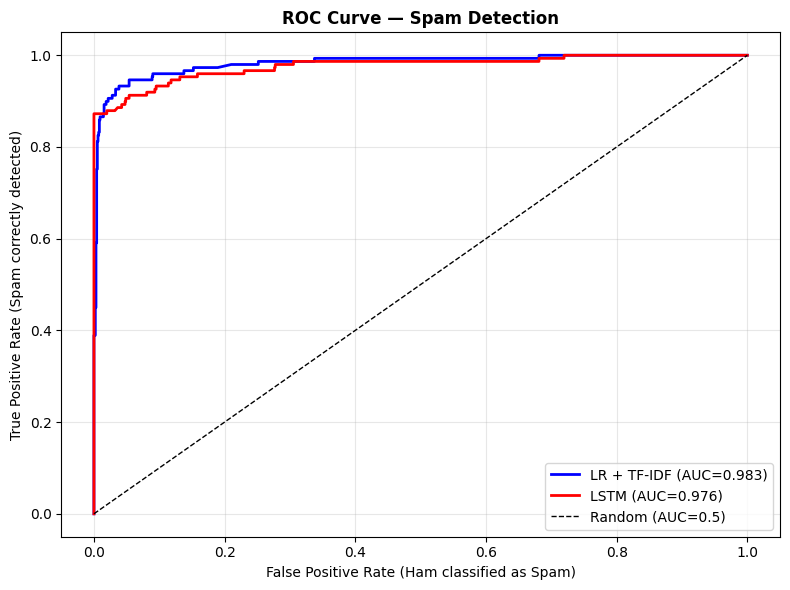

LR + TF-IDF AUC : 0.9827
LSTM AUC        : 0.9763
AUC closer to 1.0 = better at separating spam from ham


In [ ]:
# ================================================================
# 6.2  ROC CURVE — Logistic Regression (TF-IDF)
# ================================================================
# ROC curve shows how well the model separates ham from spam
# at different probability thresholds.
# AUC (Area Under Curve): 1.0 = perfect, 0.5 = random guessing

# Get probability scores (not binary predictions)
lr_tfidf_probs = lr_tfidf.predict_proba(X_test_tfidf)[:, 1]  # prob of spam
lstm_probs     = y_pred_lstm_prob

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_tfidf_probs)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, lstm_probs)

auc_lr   = auc(fpr_lr, tpr_lr)
auc_lstm = auc(fpr_lstm, tpr_lstm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr,   tpr_lr,   'b-', linewidth=2, label=f'LR + TF-IDF (AUC={auc_lr:.3f})')
plt.plot(fpr_lstm, tpr_lstm, 'r-', linewidth=2, label=f'LSTM (AUC={auc_lstm:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.5)')
plt.title('ROC Curve — Spam Detection', fontweight='bold', fontsize=12)
plt.xlabel('False Positive Rate (Ham classified as Spam)')
plt.ylabel('True Positive Rate (Spam correctly detected)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"LR + TF-IDF AUC : {auc_lr:.4f}")
print(f"LSTM AUC        : {auc_lstm:.4f}")
print("AUC closer to 1.0 = better at separating spam from ham")

---
## Task 7: Visualizations
### 7.1 — Confusion Matrices

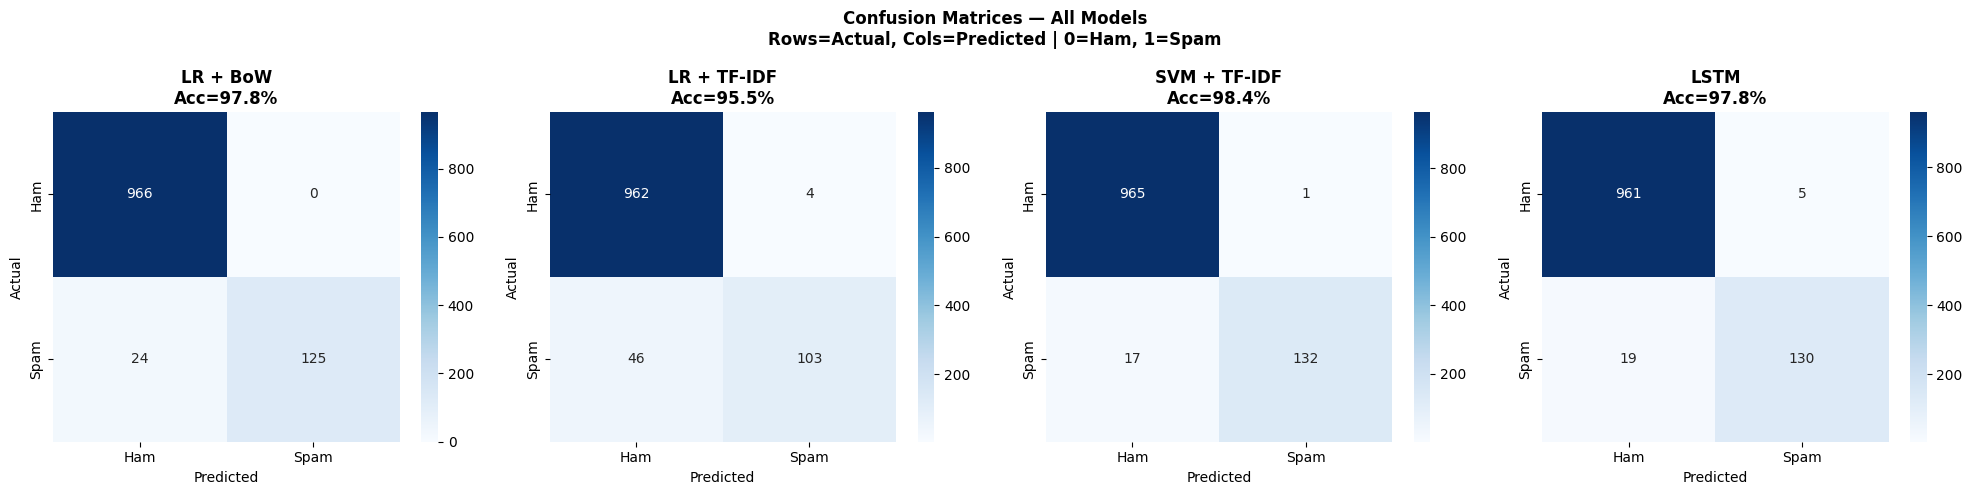

In [ ]:
# ================================================================
# 7.1  CONFUSION MATRICES — Best 4 models
# ================================================================
# Confusion Matrix reads:
#   Row = Actual class, Column = Predicted class
#   Top-left  = Ham correctly predicted as Ham (True Negative)
#   Top-right = Ham wrongly predicted as Spam (False Positive)
#   Bot-left  = Spam wrongly predicted as Ham (False Negative) ← bad!
#   Bot-right = Spam correctly predicted as Spam (True Positive)

models_for_cm = [
    ('LR + BoW',    y_test,     y_pred_lr_bow),
    ('LR + TF-IDF', y_test,     y_pred_lr_tfidf),
    ('SVM + TF-IDF',y_test,     y_pred_svm),
    ('LSTM',        y_test,     y_pred_lstm),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Confusion Matrices — All Models\n'
             'Rows=Actual, Cols=Predicted | 0=Ham, 1=Spam',
             fontsize=12, fontweight='bold')

for ax, (name, y_true, y_pred) in zip(axes, models_for_cm):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Ham', 'Spam'],
        yticklabels=['Ham', 'Spam']
    )
    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f'{name}\nAcc={acc*100:.1f}%', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

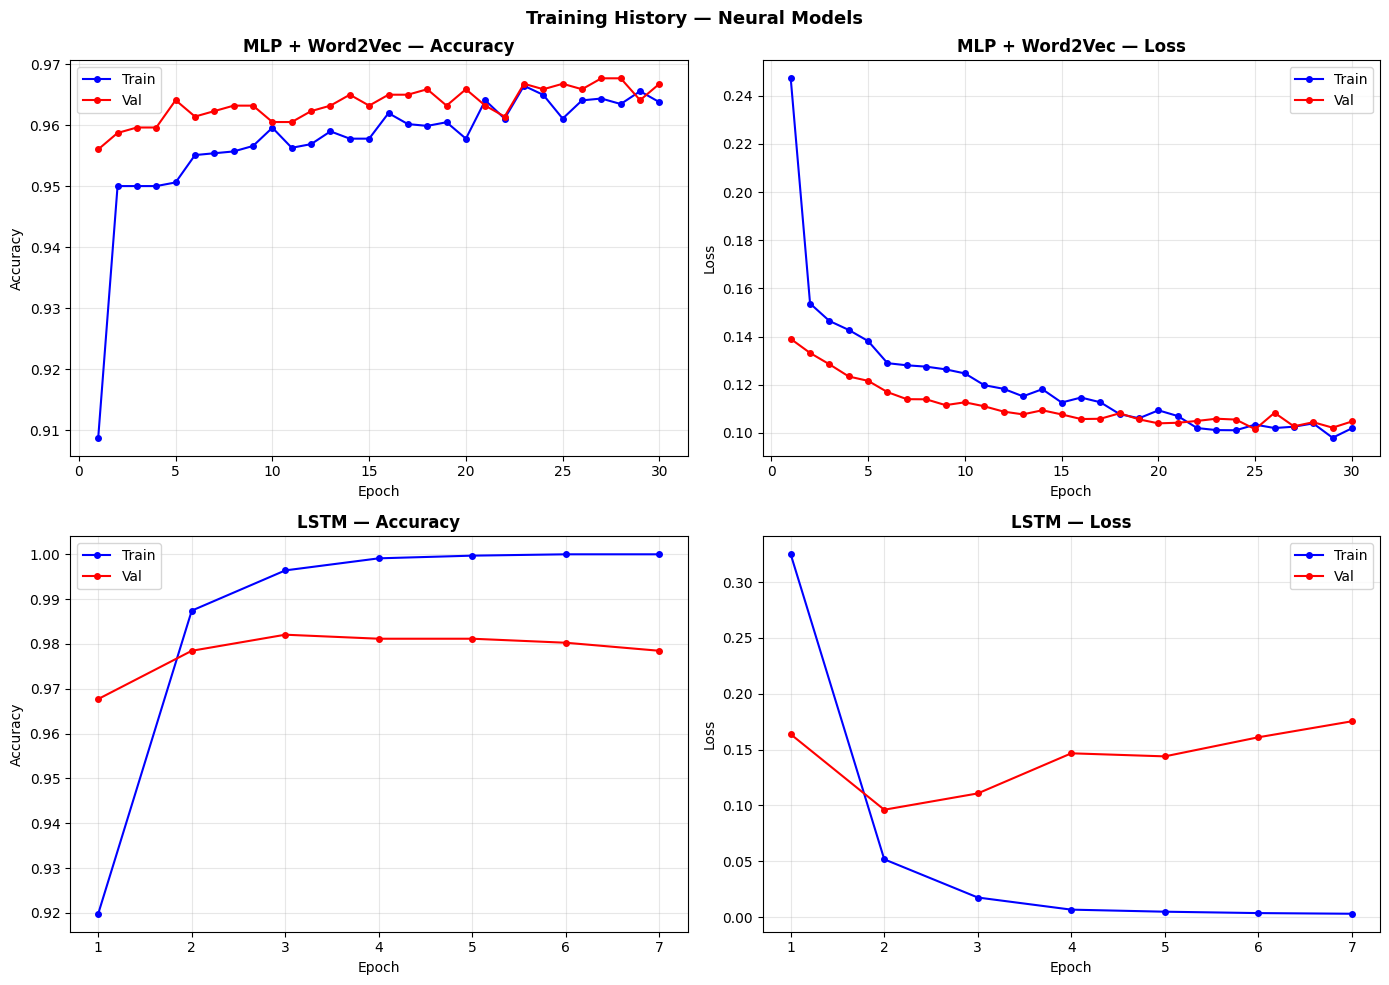

In [ ]:
# ================================================================
# 7.2  TRAINING CURVES — Neural Network and LSTM
# ================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training History — Neural Models', fontsize=13, fontweight='bold')

for row, (history, title) in enumerate([
    (history_nn,   'MLP + Word2Vec'),
    (history_lstm, 'LSTM')
]):
    ep = range(1, len(history.history['accuracy']) + 1)

    # Accuracy
    axes[row, 0].plot(ep, history.history['accuracy'],     'b-o', ms=4, label='Train')
    axes[row, 0].plot(ep, history.history['val_accuracy'], 'r-o', ms=4, label='Val')
    axes[row, 0].set_title(f'{title} — Accuracy', fontweight='bold')
    axes[row, 0].set_xlabel('Epoch'); axes[row, 0].set_ylabel('Accuracy')
    axes[row, 0].legend(); axes[row, 0].grid(alpha=0.3)

    # Loss
    axes[row, 1].plot(ep, history.history['loss'],     'b-o', ms=4, label='Train')
    axes[row, 1].plot(ep, history.history['val_loss'], 'r-o', ms=4, label='Val')
    axes[row, 1].set_title(f'{title} — Loss', fontweight='bold')
    axes[row, 1].set_xlabel('Epoch'); axes[row, 1].set_ylabel('Loss')
    axes[row, 1].legend(); axes[row, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

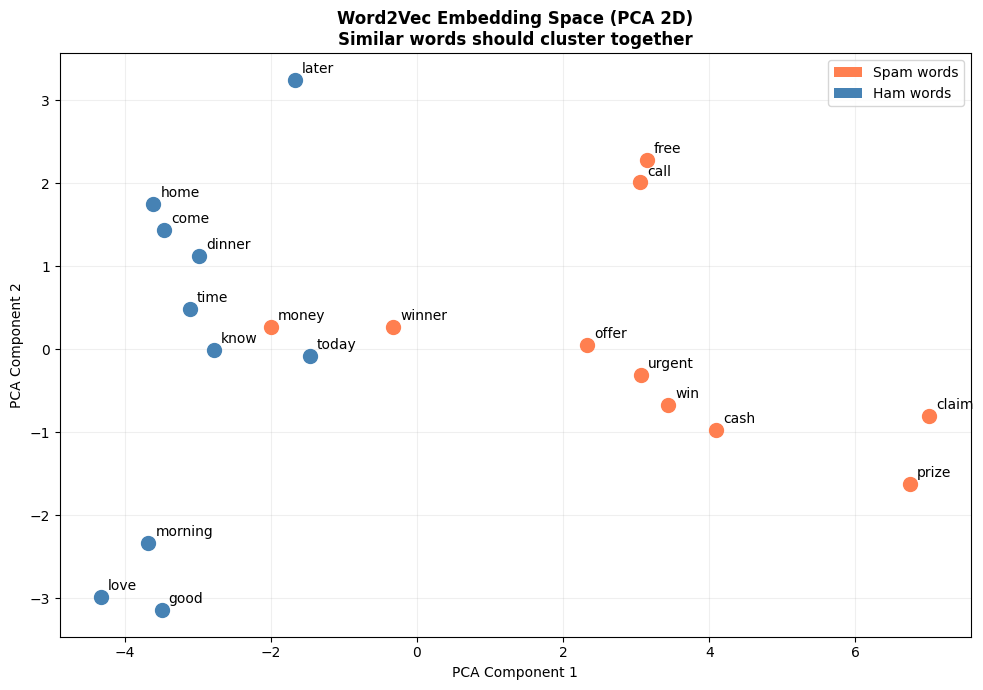

Spam words should cluster separately from ham words!


In [ ]:
# ================================================================
# 7.3  t-SNE VISUALIZATION — Word2Vec Embedding Space
# ================================================================
# We pick common spam and ham words and visualize them in 2D
# Words with similar meaning should cluster together

# Words to visualize
spam_keywords = ['free', 'win', 'winner', 'prize', 'claim', 'cash',
                 'urgent', 'call', 'money', 'offer']
ham_keywords  = ['home', 'come', 'dinner', 'today', 'later', 'morning',
                 'know', 'love', 'good', 'time']

# Filter to words actually in vocabulary
spam_in_vocab = [w for w in spam_keywords if w in w2v_model.wv]
ham_in_vocab  = [w for w in ham_keywords  if w in w2v_model.wv]
all_viz_words = spam_in_vocab + ham_in_vocab

if len(all_viz_words) >= 4:
    # Get vectors for each word
    vectors = np.array([w2v_model.wv[w] for w in all_viz_words])
    labels  = (['spam'] * len(spam_in_vocab)) + (['ham'] * len(ham_in_vocab))

    # Reduce to 2D with PCA (fast)
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(vectors)

    plt.figure(figsize=(10, 7))
    colors = {'spam': 'coral', 'ham': 'steelblue'}
    for word, coord, label in zip(all_viz_words, coords, labels):
        plt.scatter(coord[0], coord[1], color=colors[label], s=100, zorder=3)
        plt.annotate(word, (coord[0], coord[1]),
                     textcoords='offset points', xytext=(5, 5), fontsize=10)

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='coral',     label='Spam words'),
                       Patch(facecolor='steelblue', label='Ham words')]
    plt.legend(handles=legend_elements)
    plt.title('Word2Vec Embedding Space (PCA 2D)\n'
              'Similar words should cluster together', fontweight='bold')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
    print("Spam words should cluster separately from ham words!")
else:
    print("Not enough words in vocabulary for visualization — try with full dataset.")

===== All Models — Performance Summary =====
         Model  Accuracy  Precision  Recall     F1
      LR + BoW    0.9785     1.0000  0.8389 0.9124
   LR + TF-IDF    0.9552     0.9626  0.6913 0.8047
  SVM + TF-IDF    0.9839     0.9925  0.8859 0.9362
 LR + Word2Vec    0.9507     0.8406  0.7785 0.8084
MLP + Word2Vec    0.9614     0.8955  0.8054 0.8481
          LSTM    0.9785     0.9630  0.8725 0.9155



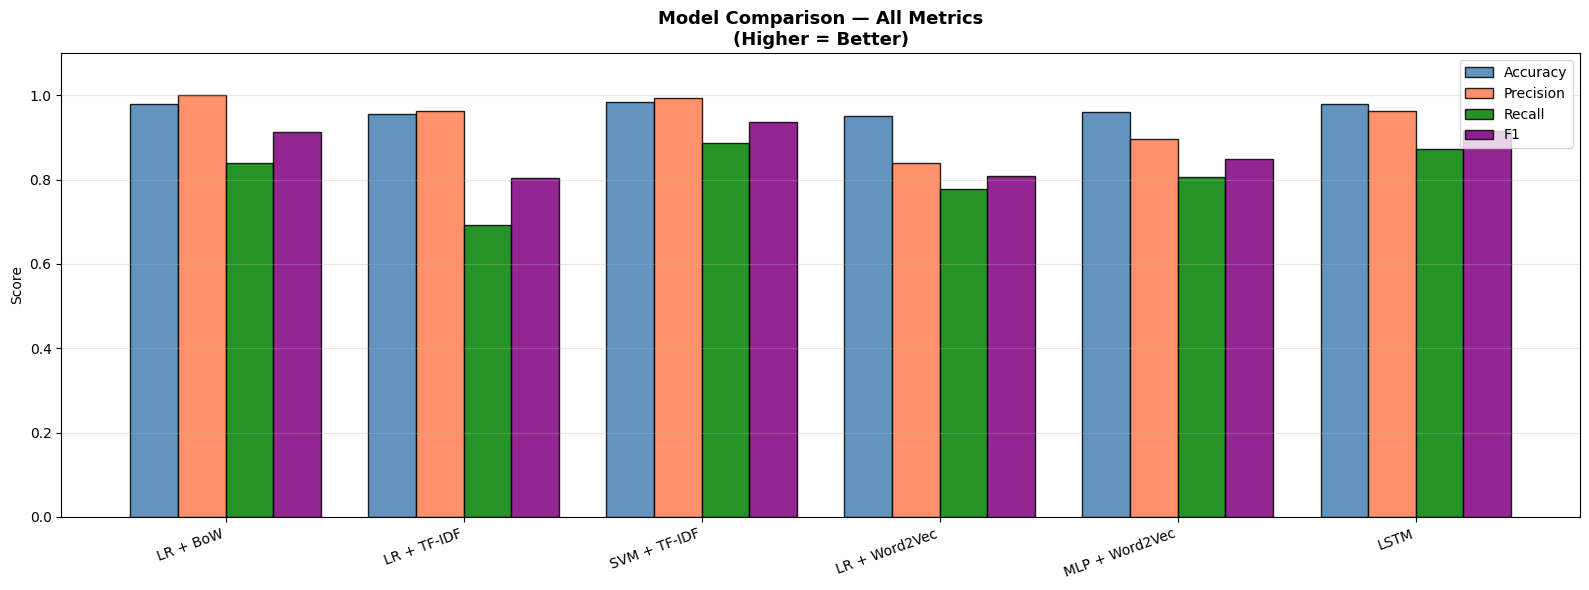

In [ ]:
# ================================================================
# 7.4  FINAL MODEL COMPARISON BAR CHART
# ================================================================

results_df = pd.DataFrame(all_results)

# Show table
print("===== All Models — Performance Summary =====")
print(results_df[['Model','Accuracy','Precision','Recall','F1']].to_string(index=False, float_format='{:.4f}'.format))
print()

# Bar chart
x     = np.arange(len(results_df))
width = 0.2
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
colors  = ['steelblue', 'coral', 'green', 'purple']

fig, ax = plt.subplots(figsize=(16, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, results_df[metric],
                  width, label=metric, color=color, alpha=0.85, edgecolor='black')

ax.set_title('Model Comparison — All Metrics\n(Higher = Better)', fontweight='bold', fontsize=13)
ax.set_ylabel('Score')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax.set_ylim([0, 1.1])
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Additional Task: Embedding Dimension Comparison


Training Word2Vec with dim=50...
  dim= 50 → Accuracy=93.54%  F1=0.7353

Training Word2Vec with dim=100...
  dim=100 → Accuracy=92.83%  F1=0.6970

Training Word2Vec with dim=200...
  dim=200 → Accuracy=92.91%  F1=0.6973


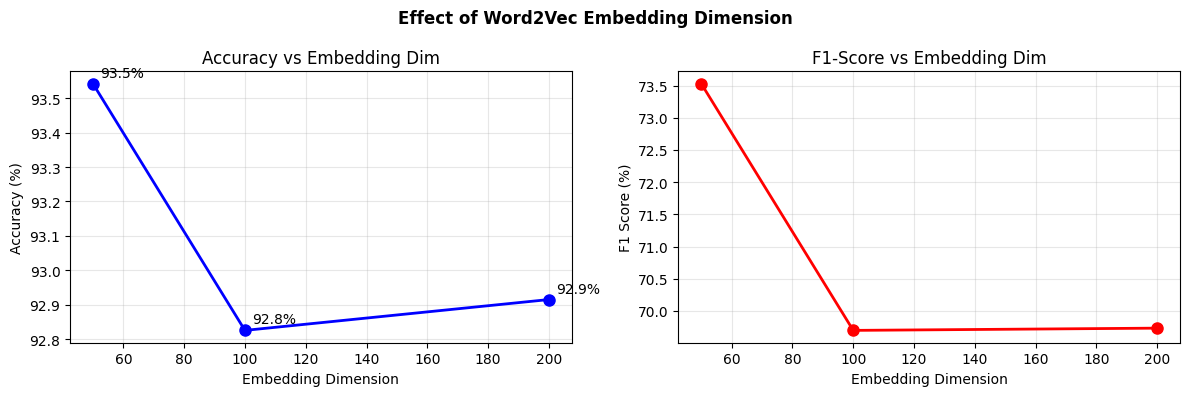

In [ ]:
# ================================================================
# ADDITIONAL: COMPARE EMBEDDING DIMENSIONS — 50, 100, 200
# ================================================================
# Does a bigger Word2Vec embedding help with classification?

embed_dims    = [50, 100, 200]
embed_results = []

for dim in embed_dims:
    print(f"\nTraining Word2Vec with dim={dim}...")

    # Train Word2Vec with this dimension
    m = Word2Vec(
        sentences=all_token_lists,
        vector_size=dim, window=5,
        min_count=2, workers=4, epochs=10, seed=42
    )

    # Build message vectors using the correctly split and tokenized data
    tr = np.array([message_to_vector(t, m, dim) for t in X_train_w2v_tokens])
    te = np.array([message_to_vector(t, m, dim) for t in X_test_w2v_tokens])

    # Train Logistic Regression
    clf = LogisticRegression(max_iter=500, random_state=42)
    clf.fit(tr, y_train_w2v)
    preds = clf.predict(te)

    acc = accuracy_score(y_test_w2v, preds)
    f1  = f1_score(y_test_w2v, preds)
    embed_results.append({'dim': dim, 'accuracy': acc, 'f1': f1})
    print(f"  dim={dim:>3} → Accuracy={acc*100:.2f}%  F1={f1:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Effect of Word2Vec Embedding Dimension', fontweight='bold')
dims  = [r['dim'] for r in embed_results]
accs  = [r['accuracy']*100 for r in embed_results]
f1s   = [r['f1']*100 for r in embed_results]

axes[0].plot(dims, accs, 'b-o', linewidth=2, markersize=8)
axes[0].set_title('Accuracy vs Embedding Dim')
axes[0].set_xlabel('Embedding Dimension')
axes[0].set_ylabel('Accuracy (%)')
axes[0].grid(alpha=0.3)
for d, a in zip(dims, accs):
    axes[0].annotate(f'{a:.1f}%', (d, a), textcoords='offset points', xytext=(5,5))

axes[1].plot(dims, f1s, 'r-o', linewidth=2, markersize=8)
axes[1].set_title('F1-Score vs Embedding Dim')
axes[1].set_xlabel('Embedding Dimension')
axes[1].set_ylabel('F1 Score (%)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Final Summary

In [ ]:
# ================================================================
# FINAL SUMMARY
# ================================================================

print("=" * 70)
print("   AIML Lab Week 10 — NLP Text Classification — Final Summary")
print("=" * 70)
print()
print("DATASET:")
print(f"  SMS Spam Collection — {len(df)} messages")
print(f"  Ham: {(df['label']=='ham').sum()} messages | Spam: {(df['label']=='spam').sum()} messages")
print()
print("PREPROCESSING STEPS APPLIED:")
print("  Lowercase → URL removal → Punctuation removal → Tokenization")
print("  → Stopword removal → Lemmatization")
print()
print("FEATURE EXTRACTION:")
print(f"  BoW     : {X_train_bow.shape[1]:,} features | Sparsity: {sparsity_bow:.1f}%")
print(f"  TF-IDF  : {X_train_tfidf.shape[1]:,} features | Sparsity: {sparsity_tfidf:.1f}%")
print(f"  Word2Vec: {EMBEDDING_DIM} features | Dense (no sparsity)")
print()
print("MODEL PERFORMANCE (Test Set):")
print(f"  {'Model':<20} {'Accuracy':>10} {'Precision':>11} {'Recall':>9} {'F1':>8}")
print("  " + "-" * 60)
for r in all_results:
    print(f"  {r['Model']:<20} {r['Accuracy']*100:>9.2f}%  {r['Precision']:>10.4f}  {r['Recall']:>8.4f}  {r['F1']:>7.4f}")
print()
best = max(all_results, key=lambda x: x['F1'])
print(f"BEST MODEL: {best['Model']} with F1={best['F1']:.4f} and Accuracy={best['Accuracy']*100:.2f}%")
print()
print("KEY CONCLUSIONS:")
print("  1. Text must be cleaned before any ML model can use it")
print("  2. TF-IDF outperforms BoW because it weights rare/important words higher")
print("  3. Word2Vec creates dense embeddings — similar words cluster in vector space")
print("  4. LSTM captures word order context which BoW/TF-IDF miss entirely")
print("  5. Even simple Logistic Regression + TF-IDF achieves very high spam accuracy")
print("  6. Recall for spam is critical — missing a spam is costly")

   AIML Lab Week 10 — NLP Text Classification — Final Summary

DATASET:
  SMS Spam Collection — 5572 messages
  Ham: 4825 messages | Spam: 747 messages

PREPROCESSING STEPS APPLIED:
  Lowercase → URL removal → Punctuation removal → Tokenization
  → Stopword removal → Lemmatization

FEATURE EXTRACTION:
  BoW     : 5,000 features | Sparsity: 99.9%
  TF-IDF  : 5,000 features | Sparsity: 99.9%
  Word2Vec: 100 features | Dense (no sparsity)

MODEL PERFORMANCE (Test Set):
  Model                  Accuracy   Precision    Recall       F1
  ------------------------------------------------------------
  LR + BoW                 97.85%      1.0000    0.8389   0.9124
  LR + TF-IDF              95.52%      0.9626    0.6913   0.8047
  SVM + TF-IDF             98.39%      0.9925    0.8859   0.9362
  LR + Word2Vec            95.07%      0.8406    0.7785   0.8084
  MLP + Word2Vec           96.14%      0.8955    0.8054   0.8481
  LSTM                     97.85%      0.9630    0.8725   0.9155

BEST MODEL